# Capstone: Optimizing Waste Management Operations

Welcome to this capstone project, where you will apply data analytics skills to a real-world sustainability problem.

## Background:
You've joined the analytics team at **GreenCycle**, a company that manages household and commercial waste collection for a mid-sized metropolitan area. City leadership wants to increase the share of waste that is **diverted from landfill** (i.e., recycled or composted) and to run collection routes more efficiently. You've been given a year's worth of route-level collection data and asked to help answer questions like:

- Which factors are associated with higher landfill diversion?
- Which routes are operating inefficiently, and what do they have in common?
- Can we build a model that predicts a route's diversion rate from its operational characteristics — and use it to guide where to invest (more bins, better education, different collection methods)?

You will work through data cleaning, exploratory analysis, and predictive modelling using the `WasteManagementData.csv` dataset, which contains **60,000 simulated waste-collection route records**.

### Dataset columns

| Column | Description |
|---|---|
| `CollectionId` | Unique identifier for the collection route/record |
| `CollectionDate` | Date of the collection |
| `Region` | Service region (Central, North, South, East, West) |
| `WasteType` | Household, Recyclable, Organic, Construction, Hazardous |
| `CollectionMethod` | Curbside, DropOff, Commercial |
| `VehicleType` | Compactor, FlatbedContainer, RecyclingTruck, VacuumTruck |
| `FuelType` | Diesel, CNG, Electric |
| `RouteDistanceKm` | Total distance driven on the route |
| `RouteDurationMin` | Total time spent on the route |
| `FuelUsedLiters` | Fuel consumed (0 for electric vehicles) |
| `HouseholdsServed` | Number of households on the route |
| `BinsCollected` | Number of bins emptied |
| `NumberOfBinsPerHousehold` | Average number of distinct bin types available per household (1 = trash only, up to 4 = trash/recycling/organics/other) |
| `PopulationDensity` | People per km² in the served area |
| `AverageHouseholdIncomeUSD` | Average household income in the served area |
| `EstimatedWeightKg` | Weight the dispatch system predicted for the route |
| `WeightCollectedKg` | Actual weight recorded at the weighbridge |
| `ContaminationRatePct` | % of the collected load that is contaminated (wrong material mixed in) |
| `DiversionRatePct` | % of the collected load diverted from landfill (recycled/composted) — **key KPI** |
| `MissedCollections` | Number of missed pickups on the route |
| `CostUSD` | Total operating cost of the route |
| `CO2EmissionsKg` | Estimated CO₂ emissions from the route |

## Table of Contents
- [Step 1: Importing Libraries](#step-1)
- [Step 2: Load and Clean the Data](#step-2)
    - [Load the data](#load-the-data)
    - [Cleaning the Dataset](#cleaning-the-dataset)
        - [Exercise 1: Set Index](#ex1)
- [Step 3: Retrieving Key Metrics](#step-3)
    - [Describing the Dataset](#describing-the-dataset)
        - [Exercise 2: Descriptive Statistics](#ex2)
    - [Inefficient Routes](#inefficient-routes)
        - [Exercise 3: Identifying Inefficient Routes](#ex3)
- [Step 4: Understanding Different Route Profiles](#step-4)
    - [Visualization of Different Profiles](#visualization-of-different-profiles)
        - [Exercise 4: Boxplots by Waste Type](#ex4)
        - [Exercise 5: Scatter Plots and Correlation](#ex5)
    - [Estimated vs Actual Weight](#estimated-and-actual-weight)
        - [Exercise 6: Confidence Intervals](#ex6)
- [Step 5: Modelling the Diversion Rate](#step-5)
    - [Exercise 7: Simple Linear Regression](#ex7)
    - [Exercise 8: Building a More Complex Model](#ex8)

<a id="step-1"></a>

## Step 1: Importing libraries

Before you start working on the dataset, it is good practice to import all libraries at the beginning of your code.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Run the cell below to import the following libraries: Pandas, Matplotlib's Pyplot and Seaborn.

</div>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from math import sqrt

<a id="step-2"></a>

## Step 2: Load and Clean the Data

<a id="load-the-data"></a>

### Load the Data
Now that you have imported the right libraries, you can use Pandas to load the data from the CSV.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Run the cell below to:
    1. Import the data
    2. Save the DataFrame into a variable named <code>df</code>
    3. View the data using <code>head()</code>

</div>

In [ ]:
# 🔒This cell is locked. You will not be able to edit it.
# load the data
df = pd.read_csv("data/WasteManagementData.csv")
df.head()

<a id="cleaning-the-dataset"></a>

### Cleaning the Dataset

Before starting your analysis, take some time to familiarize yourself with the dataset — check its size, column types, and whether there are any missing values.

<a id="ex1"></a>

#### Exercise 1: Set the Index

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Use <code>.info()</code> and <code>.isna().sum()</code> to explore the dataset.
2. Set the <code>"CollectionId"</code> column as the DataFrame's index, and reassign the result back to <code>df</code>.

</div>

In [ ]:
# explore the dataset — shape, dtypes, missing values
df.info()
df.isna().sum()

In [ ]:
# GRADED CELL: exercise 1

### START CODE HERE ###

# set the "CollectionId" column as index
df.None

### END CODE HERE ###

In [ ]:
# 🔒This cell is locked. You will not be able to edit it.
# check the index is correct
df.index.name

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
'CollectionId'
```


</details>

<a id="step-3"></a>

## Step 3: Retrieving Key Metrics

To recommend operational improvements, take a moment to understand collection volumes and diversion outcomes. You'll also want a rough idea of how many routes deviate from what the dispatch system expected.

<a id="describing-the-dataset"></a>

### Describing the Dataset

<a id="ex2"></a>

#### Exercise 2: Descriptive Statistics

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Find the sample mean and standard deviation of the <code>"DiversionRatePct"</code> column.
2. Find the number of routes where the actual <code>"WeightCollectedKg"</code> was **less than** the <code>"EstimatedWeightKg"</code> predicted by dispatch (i.e., under-collection).
3. Find the proportion of records for each <code>"WasteType"</code>.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To get the sample mean and standard deviation you can use the `mean()` and `std()` methods on a Series.
- To count how many rows satisfy a condition, build a boolean mask (e.g. `df["A"] < df["B"]`) and call `.sum()` on it.
- To get value counts as proportions, use `value_counts()` and divide by `len(df)`, or pass `normalize=True` directly to `value_counts()`.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 2

### START CODE HERE ###

# find the sample mean and std of the "DiversionRatePct" column
diversion_mean = None
diversion_std = None

# find the number of routes that collected less weight than the dispatch system estimated
num_undercollected = None

# find the proportion of records for each waste type
wastetype_proportion = None/len(df)

### END CODE HERE ###

In [ ]:
# 🔒This cell is locked. You will not be able to edit it.
# print the results
print("Diversion rate mean:", round(diversion_mean, 2))
print("Diversion rate standard deviation:", round(diversion_std, 2))
print("Number of routes that under-collected relative to the estimate:", num_undercollected)
print("Proportion of records by waste type:\n", wastetype_proportion.sort_index())

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
Diversion rate mean: 42.33
Diversion rate standard deviation: 26.36
Number of routes that under-collected relative to the estimate: 33360
Proportion of records by waste type:
 WasteType
Construction    0.098833
Hazardous       0.050917
Household       0.440317
Organic         0.161700
Recyclable      0.248233
Name: proportion, dtype: float64
```


</details>

<a id="inefficient-routes"></a>

### Inefficient Routes

Routes with poor service reliability and limited recycling infrastructure are harder — and more expensive — to improve. You want to flag these routes so operations can prioritize them.

<a id="ex3"></a>

#### Exercise 3: Identifying Inefficient Routes

A route is considered **inefficient** if it had **2 or more missed collections** *and* serves households with **only 1 bin type** available (i.e., no separate recycling or organics bin — `NumberOfBinsPerHousehold == 1`).

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Create a new column <code>"IsInefficient"</code> that is <code>True</code> where both conditions above hold.
2. Calculate the proportion of inefficient routes.
3. Calculate the mean diversion rate of inefficient routes.
4. Calculate the mean diversion rate of non-inefficient routes.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To combine two boolean conditions element-wise, use `&` (not `and`), and wrap each condition in parentheses: `(cond1) & (cond2)`.
- The proportion of `True` values in a boolean column is the same as its mean — `.mean()` treats `True` as 1 and `False` as 0.
- Use boolean indexing (e.g. `df.loc[df["IsInefficient"], "DiversionRatePct"]`) to select just the rows you need before taking the mean.

</ul>
</details>

In [ ]:
# GRADED CELL: exercise 3

### START CODE HERE ###

# create a new column "IsInefficient" that is True if the route is inefficient
df["IsInefficient"] = None

# calculate the proportion of inefficient routes
inefficient_proportion = None

# calculate the mean diversion rate of inefficient routes
mean_diversion_inefficient = None

# calculate the mean diversion rate of non-inefficient routes
mean_diversion_efficient = None

### END CODE HERE ###

In [ ]:
# 🔒This cell is locked. You will not be able to edit it.
# print the results
print("Inefficient routes proportion:", round(inefficient_proportion, 4))
print("Mean diversion rate of inefficient routes:", round(mean_diversion_inefficient, 4))
print("Mean diversion rate of non-inefficient routes:", round(mean_diversion_efficient, 4))

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
Inefficient routes proportion: 0.0852
Mean diversion rate of inefficient routes: 36.5205
Mean diversion rate of non-inefficient routes: 42.8667
```


</details>

**Reflect:** Inefficient routes divert noticeably less waste from landfill than the rest of the network. What does this suggest about the relationship between service reliability, recycling infrastructure (bin availability), and environmental outcomes? Which would you prioritize fixing first — the missed collections, or the bin infrastructure — and why?

<a id="step-4"></a>

## Step 4: Understanding Different Route Profiles

As an analyst, understanding how different operational factors relate to landfill diversion helps you identify what actually moves the needle.

<a id="visualization-of-different-profiles"></a>

### Visualization of Different Profiles

<a id="ex4"></a>

#### Exercise 4: Boxplots by Waste Type

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Create a figure of size (10, 6).
2. Create a boxplot with <code>"WasteType"</code> on the x-axis and <code>"DiversionRatePct"</code> on the y-axis, using the <code>"Greens"</code> color palette.
3. Label the x-axis <code>"Waste Type"</code>.
4. Title the plot <code>"Diversion Rate Distribution by Waste Type"</code>.
5. Despine the plot.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To create the boxplot, use `sns.boxplot(data=..., x=..., y=..., palette=...)`.
- Axis labels can be set with `.set_xlabel()` on the Axes object returned by `sns.boxplot()`.
- Use `sns.despine()` to remove the top and right plot borders.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 4

### START CODE HERE ###

# create the figure with size (10,6)
plt.figure(figsize=(10,6))

# create the diversion rate by waste type plot
boxplot_ax = sns.None(None, None, None, None)

# set the x-axis label
None

# set the title
None

# despine the plot
None

### END CODE HERE ###

plt.tight_layout()
plt.show()

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>

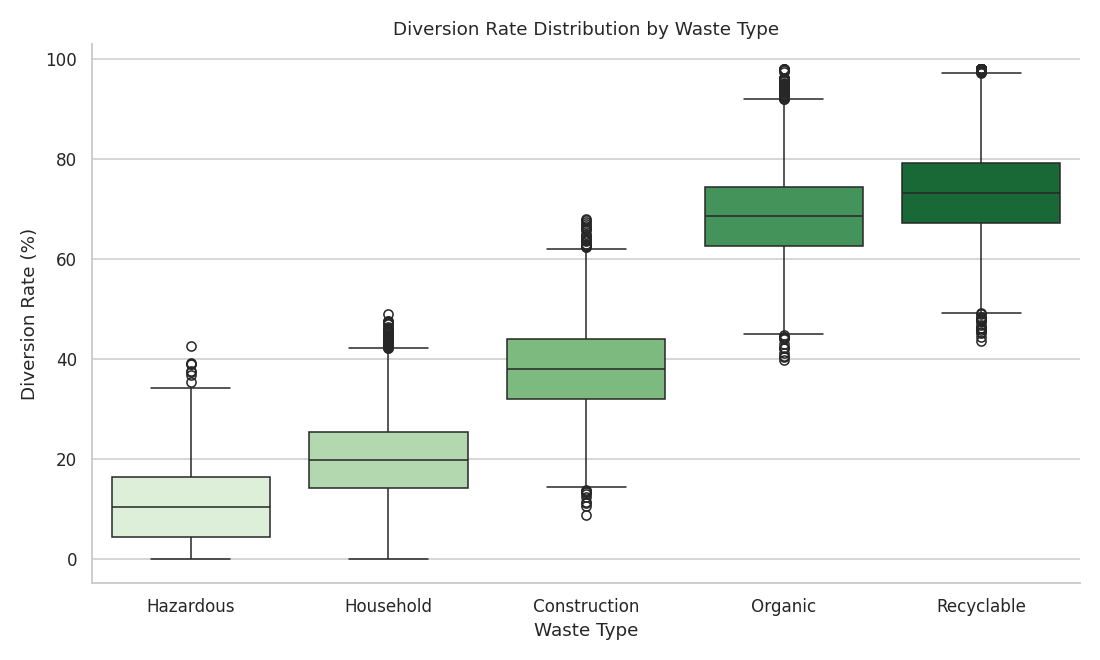

</details>

<a id="ex5"></a>

#### Exercise 5: Scatter Plots and Correlation

You also want to investigate the relationship between numerical route characteristics and the diversion rate.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Create a list named <code>corr_columns</code> containing: <code>"RouteDistanceKm"</code>, <code>"PopulationDensity"</code>, <code>"NumberOfBinsPerHousehold"</code>, <code>"AverageHouseholdIncomeUSD"</code>.
2. For each column, create a scatter plot against <code>"DiversionRatePct"</code> as a subplot in a 2x2 grid, and print its correlation with <code>"DiversionRatePct"</code>.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To create a new subplot, use `plt.subplot(2, 2, i)`. Remember `i` should range from 1 to 4, not 0 to 3.
- To compute a correlation between two Series, use `.corr()`, e.g. `df["A"].corr(df["B"])`.
- Store each correlation value in the `correlation` list so you can inspect them afterwards.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 5

scatterplot_fig = plt.figure(figsize=(12, 8))

# create a list to store the correlation values
correlation = []

# create a list of columns to correlate against diversion rate
corr_columns = None

### START CODE HERE ###

# iterate over the values 1-4 (one for each subplot)
for i in None:

    # get the column name. Remember to subtract 1 from i to match the list's indexing
    column_name = None

    plt.subplot(2, 2, i)
    sns.scatterplot(data=df.sample(5000, random_state=42), x=column_name, y="DiversionRatePct", alpha=0.3, s=15)
    plt.title(f"Diversion Rate vs {column_name}")

    corr_value = None
    correlation.append(corr_value)
    print(f"Correlation between Diversion Rate and {column_name}:")
    print(round(corr_value, 4))

### END CODE HERE ###

plt.tight_layout()
plt.show()

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```
Correlation between Diversion Rate and RouteDistanceKm:
-0.0443
Correlation between Diversion Rate and PopulationDensity:
0.0812
Correlation between Diversion Rate and NumberOfBinsPerHousehold:
0.1692
Correlation between Diversion Rate and AverageHouseholdIncomeUSD:
0.1219
```

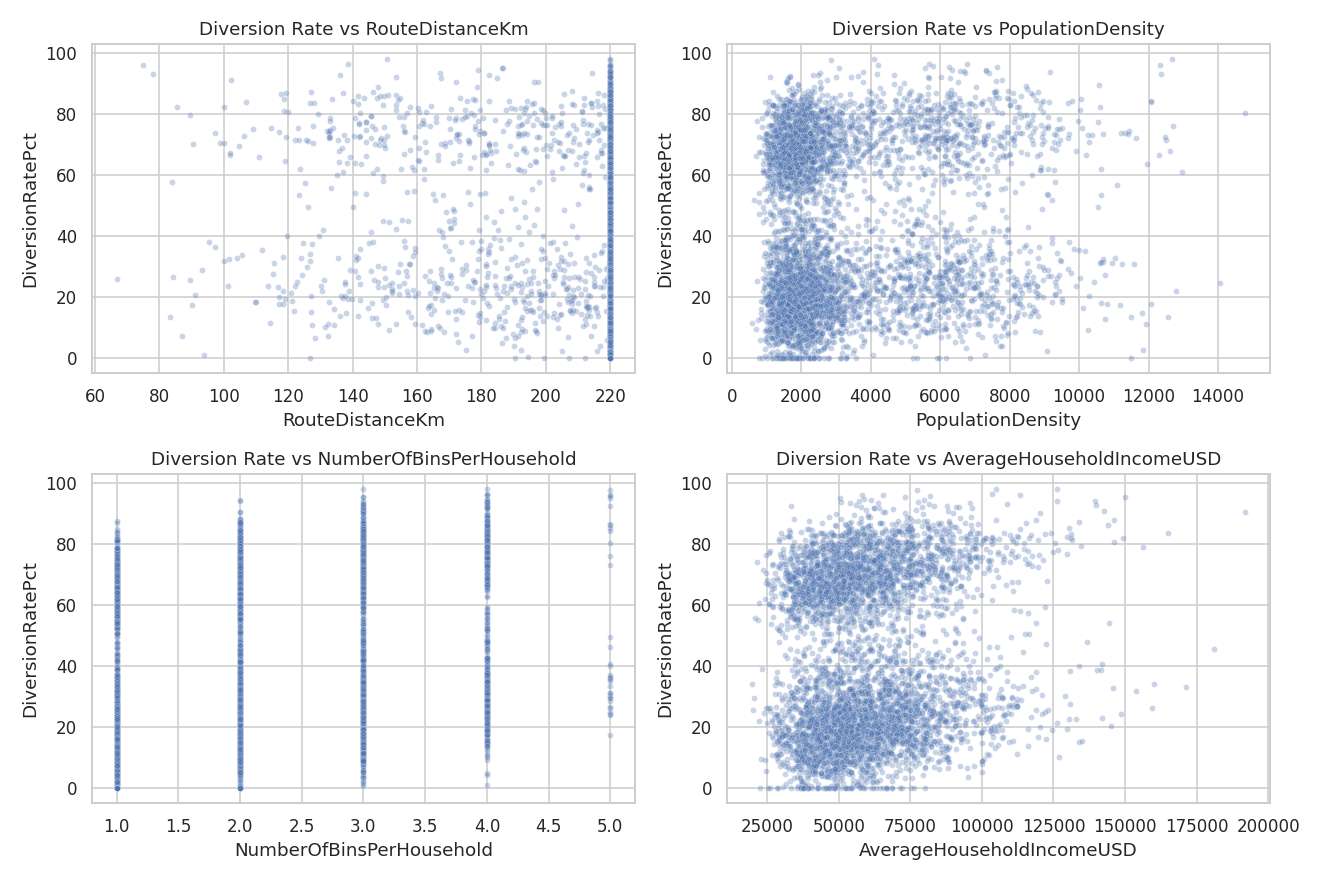


</details>

What can you say about these different features individually? None of them show a strong linear relationship with diversion rate on their own — which ones do you think are most promising, and why might none of them, alone, tell the full story?

<a id="estimated-and-actual-weight"></a>

### Estimated vs Actual Weight

You noticed that there are two similar columns, `"EstimatedWeightKg"` and `"WeightCollectedKg"`. This implies that the dispatch system's prediction doesn't always match what actually gets weighed at the facility.

<a id="ex6"></a>

#### Exercise 6: Confidence Intervals

If more than half of routes are under-collecting relative to the dispatch estimate, that could point to a systemic issue (e.g., skipped stops, blocked bins, truck capacity limits) worth investigating.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Get the number of routes where <code>"WeightCollectedKg"</code> is less than <code>"EstimatedWeightKg"</code>.
2. Get the total number of records.
3. Calculate the sample proportion.
4. Calculate the standard error for proportions.
5. Build the 95% confidence interval for the true proportion of under-collecting routes.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To find the number of routes where the actual weight is less than estimated, compare the two columns directly and sum the boolean result.
- The standard error for a proportion is `sqrt(phat * (1 - phat) / n)`.
- For a 95% confidence interval, use the z-score `stats.norm.ppf(0.975)` and build the interval as `(phat - z*se, phat + z*se)`.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 6

### START CODE HERE ###

# get the number of routes where "WeightCollectedKg" is less than "EstimatedWeightKg"
num_undercollected = (None < None).None()

# get the total number of records
n = None

# calculate the sample proportion
phat = None

# calculate the standard error for proportions
se = None

# build the confidence interval
confidence_interval = None

### END CODE HERE ###

In [ ]:
# 🔒This cell is locked. You will not be able to edit it.
# print the results
print("The 95% confidence interval is", confidence_interval)

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
The 95% confidence interval is (0.5520244122230966, 0.5599755877769035)
```


</details>

More than half of all routes are under-collecting relative to the dispatch system's estimate, and the confidence interval is tight given the large sample size. This is a strong signal that the estimation model (or the routes themselves) may need review — this would be a good candidate for a separate follow-up analysis.

<a id="step-5"></a>

## Step 5: Modelling the Diversion Rate

To help prioritize investments (more bin types, better routing, contamination-reduction campaigns), you decide to build a model that predicts a route's diversion rate from its characteristics. This will help you understand which features actually matter, and estimate diversion rates for new or planned routes.

<a id="ex7"></a>

#### Exercise 7: Simple Linear Regression

Of the features explored in Exercise 5, `"NumberOfBinsPerHousehold"` had the strongest correlation with diversion rate. Let's start there.

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Prepare the predictor — don't forget to add the constant term.
2. Select the dependent variable.
3. Build and fit an OLS model.
4. Print the results summary.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To add a constant term to your predictors, use `sm.add_constant(...)`.
- Build the model with `sm.OLS(Y, X)` and fit it with `.fit()`.
- The summary is available via `.summary()` on the fitted results object.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 7

### START CODE HERE ###

# prepare predictor. do not forget to add the constant term
X_simple = None

# select the dependent variable
Y_simple = None

# build the model
model_simple = None

# fit the model
results_simple = None

# Print the results summary
print(None)

### END CODE HERE ###

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
                            OLS Regression Results
==============================================================================
Dep. Variable:       DiversionRatePct   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     1769.
No. Observations:               60000   AIC:                         5.612e+05
Df Residuals:                   59998   BIC:                         5.612e+05
Df Model:                           1
========================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       32.4634      0.257    126.143      0.000      31.959      32.968
NumberOfBinsPerHousehold     4.4219      0.105     42.061      0.000       4.216       4.628
==============================================================================
```


</details>

This next cell is not graded, so feel free to experiment. You're given the line of best fit — try adding your own visualizations.

In [ ]:
plt.figure()
sns.scatterplot(data=df.sample(5000, random_state=42), x="NumberOfBinsPerHousehold", y="DiversionRatePct", alpha=0.25, s=15)
x_range = [df["NumberOfBinsPerHousehold"].min(), df["NumberOfBinsPerHousehold"].max()]
y_pred = [results_simple.params["const"] + results_simple.params["NumberOfBinsPerHousehold"] * x for x in x_range]
plt.plot(x_range, y_pred, color="red", linewidth=2)
plt.title("Simple Linear Regression: Line of Best Fit")
plt.xlabel("Number of Bin Types per Household")
plt.ylabel("Diversion Rate (%)")
plt.show()

Does this chart make sense given the correlation you found in Exercise 5? An R² this low means bin availability alone leaves most of the variation in diversion rate unexplained.

### Building a More Complex Model

Since predicting diversion rate from a single variable didn't yield strong results, take a more comprehensive approach this time — one that also brings in **categorical** information like waste type and region.

**Reflect:** which variables would you use as predictors, and why might waste type matter more than any single numeric feature?

<a id="ex8"></a>

#### Exercise 8: Building and Refining the Model

<div style="background-color: #C6E2FF; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%">

**▶▶▶ Directions**

1. Define a list of predictor column names, including both numerical and categorical variables. Suggested predictors: <code>"ContaminationRatePct"</code>, <code>"NumberOfBinsPerHousehold"</code>, <code>"PopulationDensity"</code>, <code>"AverageHouseholdIncomeUSD"</code>, <code>"RouteDistanceKm"</code>, <code>"WasteType"</code>, <code>"Region"</code>, <code>"CollectionMethod"</code>.
2. Separately, define a list of just the categorical columns among these.
3. Create the predictors DataFrame using one-hot encoding, dropping the first category of each to avoid multicollinearity, and don't forget the constant term.
4. Create the target variable.
5. Build and fit the model, and print the summary.

</div>

<details>
<summary style="background-color: #FDBFC7; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
If you are stuck, click here for extra hints!</summary>

<ul style="background-color: #FFF8F8; padding: 10px; border-radius: 3px; margin-top: 5px; width: 95%; box-shadow: inset 0 2px 4px rgba(0, 0, 0, 0.1);">

- To get the dummy encodings, use `pd.get_dummies(df[predictors], columns=categorical, drop_first=True, dtype=int)`. You'll need to wrap this with `sm.add_constant(...)` as well.
- Make sure `predictors` includes both the numeric and categorical column names, since `pd.get_dummies` will only transform the categorical ones and pass the rest through untouched.
- Build and fit the model the same way as in Exercise 7.

</ul>
</details>

In [ ]:
# GRADED CELL: Exercise 8

### START CODE HERE ###

# define a list with the column names you want to use as predictors
# include numerical and categorical variables
predictors = None

categorical = None

# create the predictors dataframe. do not forget to add the constant term
X = None(None(df, columns=None, drop_first=None, dtype=None))

# create the target variable
Y = None

# create the model
model = None

# fit the model
results = None

### END CODE HERE ###

print(results.summary())

<details>
<summary style="background-color: #c6e2ff6c; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.01); width: 95%; text-align: left; cursor: pointer; font-weight: bold;">
Expected output:</summary>

<br>


```mkdn
                            OLS Regression Results
==============================================================================
Dep. Variable:       DiversionRatePct   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                 7.445e+04
No. Observations:               60000   AIC:                         3.844e+05
Df Residuals:                   59984   BIC:                         3.845e+05
Df Model:                          15
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        27.4928      0.382     71.951      0.000      26.744      28.242
ContaminationRatePct         -0.5482      0.008    -71.112      0.000      -0.563      -0.533
NumberOfBinsPerHousehold      3.1854      0.029    110.529      0.000       3.129       3.242
PopulationDensity             0.0003   2.29e-05     14.253      0.000       0.000       0.000
AverageHouseholdIncomeUSD  9.081e-05   1.38e-06     65.889      0.000    8.81e-05    9.35e-05
RouteDistanceKm               0.0003      0.001      0.264      0.792      -0.002       0.003
WasteType_Hazardous         -29.5411      0.136   -217.540      0.000     -29.807     -29.275
WasteType_Household         -21.8519      0.123   -178.330      0.000     -22.092     -21.612
WasteType_Organic            34.1312      0.140    244.527      0.000      33.858      34.405
WasteType_Recyclable         40.1074      0.152    263.120      0.000      39.809      40.406
Region_East                  -0.1148      0.112     -1.025      0.305      -0.334       0.105
Region_North                 -0.2671      0.120     -2.229      0.026      -0.502      -0.032
Region_South                 -0.4728      0.127     -3.709      0.000      -0.723      -0.223
Region_West                  -0.6041      0.134     -4.503      0.000      -0.867      -0.341
CollectionMethod_Curbside     1.8094      0.108     16.728      0.000       1.597       2.021
CollectionMethod_DropOff      5.8090      0.104     55.590      0.000       5.604       6.014
==============================================================================
```


</details>

**Reflect:** Notice that `ContaminationRatePct` now has a *negative* coefficient, even though it wasn't included in Exercise 7. Why might a variable's relationship with the target look completely different once other variables are controlled for? (Hint: think about which waste types tend to have both high contamination rates *and* high diversion rates, and what that does to a simple, one-variable correlation.)

This is a classic example of **confounding** — always be cautious about reading causal meaning into a single-variable correlation without checking whether a third variable is driving both sides of it.

---
Congratulations on finishing this capstone! If everything is running correctly, you can go ahead and submit your code for grading.

**Optional extension ideas**, if you want to keep going:
- Try a tree-based model (e.g., Random Forest or XGBoost) and compare its R² to the linear model above.
- Build a feature-importance plot to see which factors the model relies on most.
- Segment the "inefficient routes" flag from Exercise 3 by `Region` — are certain regions more prone to inefficiency?
- Estimate the CO₂ and cost impact of moving a fixed number of `Household`-type routes to a `NumberOfBinsPerHousehold` of 2 or more.